# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [3]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip

In [70]:
#On importe les données dans un dataframe
df1 = pd.read_excel("portefeuille_actifs+(3).xlsx") 
df2 = pd.read_excel("historique_immobilier_paris_2017_2021_vdef2.xlsx")
df3 = pd.read_excel("echantillon_a_classer2.xlsx")

#Aperçu du début du DataFrame historique immobilier
df2.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


Attention, si l'opération ci-dessus ne marche pas, il se peut que le package "openpyxl" ne soit pas présent sur votre ordinateur. Si c'est le cas vous pouvez l'installer en éxécutant la commande : pip install openpyxl ou conda install openpyxl.

In [25]:
#On vérifie que le type des données attribué par pandas est cohérent
df1.info()
df2.info()
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   adresse_numero             275 non-null    int64  
 1   adresse_nom_voie           275 non-null    object 
 2   code_postal                275 non-null    int64  
 3   code_commune               275 non-null    int64  
 4   nom_commune                275 non-null    object 
 5   surface_carrez             275 non-null    float64
 6   code_type_local            275 non-null    int64  
 7   type_local                 275 non-null    object 
 8   surface_reelle_bati        275 non-null    int64  
 9   nombre_pieces_principales  275 non-null    int64  
 10  longitude                  275 non-null    float64
 11  latitude                   275 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 25.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex

### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [32]:
print('la liste des différents types de biens immobiliers que nous avons dans les données est :')
print(df2['type_local'].unique())
print("\nCodes et types de locaux associés :")
print(df2[['code_type_local', 'type_local']].drop_duplicates().to_string(index=False))

la liste des différents types de biens immobiliers que nous avons dans les données est :
['Appartement' 'Local industriel. commercial ou assimilé']

Codes et types de locaux associés :
 code_type_local                               type_local
               2                              Appartement
               4 Local industriel. commercial ou assimilé


On observe qu'il y a 2 types de biens, et que leurs codes types sont 2 et 4. 

### 3. Nombre de transactions

In [29]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
print(f"le nombre de transactions dans les données est {len(df2)}")
print(f"le nombre de transactions pour les appartements dans les données est {len(df2[df2['type_local'] == 'Appartement'])}")
print(f"le nombre de transactions pour les locaux commerciaux dans les données est {len(df2[df2['type_local'] == 'Local industriel. commercial ou assimilé'])}")


le nombre de transactions dans les données est 26196
le nombre de transactions pour les appartements dans les données est 24353
le nombre de transactions pour les locaux commerciaux dans les données est 1843


### 4. interval de l'historique des données

In [31]:
#On vérifie également la plage de l'historique disponible

#On s'assure que la colonne date est bien interprétée au format datetime
df2['date_mutation'] = pd.to_datetime(df2['date_mutation'])

#On vérifie également la plage de l'historique disponible
print(f"la première date de transaction dans les données est le {df2['date_mutation'].min().strftime('%d/%m/%Y')}")
print(f"la dernière date de transaction dans les données est le {df2['date_mutation'].max().strftime('%d/%m/%Y')}")

la première date de transaction dans les données est le 02/01/2017
la dernière date de transaction dans les données est le 31/12/2021


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [33]:
# Calcul de la colonne
# Calcul de la colonne du prix au mètre carré
df2['prix_m2'] = df2['valeur_fonciere'] / df2['surface_reelle']

# Visualisation rapide des nouvelles données
df2[['valeur_fonciere', 'surface_reelle', 'prix_m2']].head()

,valeur_fonciere,surface_reelle,prix_m2
0,5.505597e+05,50,11011.193562
1,1.576492e+06,163,9671.732877
2,6.577574e+05,66,9966.020548
3,2.500868e+05,22,11367.582877
4,1.762667e+05,15,11751.113836


Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [34]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps
# Filtrage pour ne garder que les appartements
df_appart = df2[df2['type_local'] == 'Appartement'].copy()

# Optionnel : conservation des colonnes principales pour alléger le DataFrame
df_appart = df_appart[['date_mutation', 'valeur_fonciere', 'code_postal', 'type_local', 'surface_reelle', 'prix_m2']]

In [35]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
# Extraction de l'année à partir de la date de mutation
df_appart['date_mutation'] = pd.to_datetime(df_appart['date_mutation'])
df_appart['annee'] = df_appart['date_mutation'].dt.year

# Regroupement par année pour obtenir les moyennes demandées
df_evolution = df_appart.groupby('annee').agg({
    'prix_m2': 'mean',
    'surface_reelle': 'mean',
    'valeur_fonciere': 'mean'
}).reset_index()

# Affichage du nouveau DataFrame d'évolution
df_evolution

,annee,prix_m2,surface_reelle,valeur_fonciere
0,2017,9492.859195,44.627737,427963.238883
1,2018,10031.403432,44.271671,448055.762541
2,2019,10562.712581,43.361645,461950.057064
3,2020,10674.872650,42.900654,462383.253604
4,2021,10455.600126,43.479864,458771.507203


On constate sur la moyenne des prix de vente des appartements à Paris que les prix ont connu une hausse continue entre 2017 et 2020 (passant d'environ 9 493 €/m² à 10 675 €/m²), avant de se stabiliser avec une légère baisse en 2021 (redescendant à environ 10 456 €/m²). <br>
Nous allons créer un graphique pour mieux le visualiser.

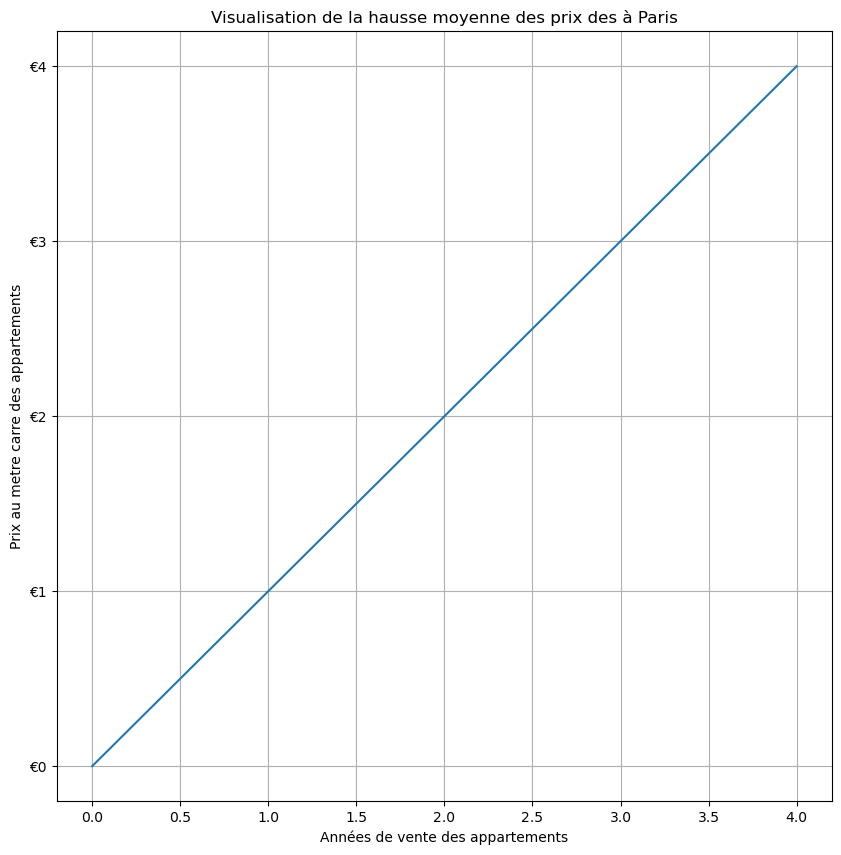

In [36]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.figure(figsize=(10,10))
plt.plot(['2017','2018','2019','2020','2021'])
plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au metre carre des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Visualisation de la hausse moyenne des prix des à Paris')
plt.show()

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [38]:
#Liste des codes postaux uniques triés dans nos données
liste_cp = sorted(df_appart['code_postal'].unique())
print("Les codes postaux présents dans nos données sont :")
print(liste_cp)

Les codes postaux présents dans nos données sont :
[np.int64(75001), np.int64(75002), np.int64(75003), np.int64(75004), np.int64(75005), np.int64(75006), np.int64(75007), np.int64(75008), np.int64(75009), np.int64(75010), np.int64(75011), np.int64(75012), np.int64(75013), np.int64(75014), np.int64(75015), np.int64(75016), np.int64(75017), np.int64(75018), np.int64(75019), np.int64(75020)]


In [39]:
#Créeons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement
#Création d'un dataframe regroupant les prix moyens au m² par année et par arrondissement
df_arrondissement = df_appart.groupby(['annee', 'code_postal'])['prix_m2'].mean().reset_index()

#Visualisation d'un aperçu du dataframe obtenu
df_arrondissement.head(10)

,annee,code_postal,prix_m2
0,2017,75001,11762.706289
1,2017,75002,10920.126562
2,2017,75003,11679.818729
3,2017,75004,12407.227522
4,2017,75005,11306.752404
5,2017,75006,12508.837036
6,2017,75007,11845.118831
7,2017,75008,10132.798372
8,2017,75009,9582.311203
9,2017,75010,8747.004273


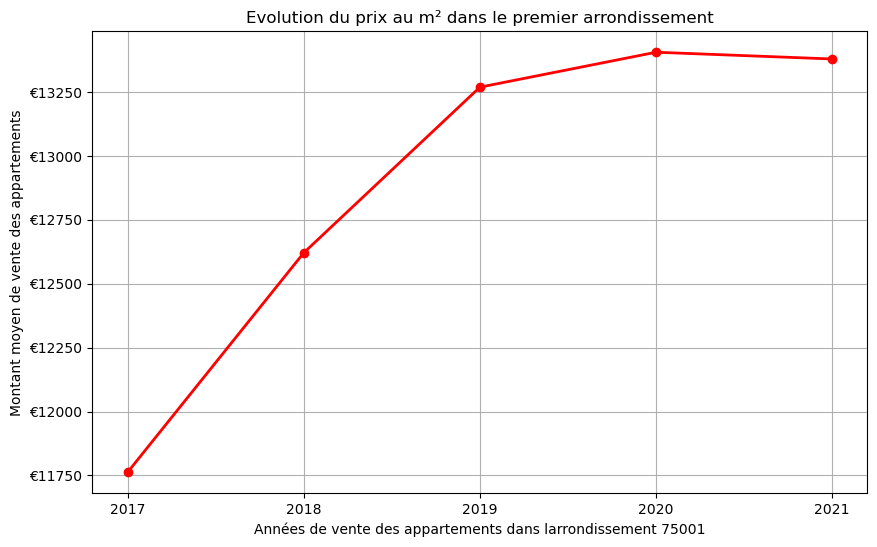

In [43]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement
plt.figure(figsize=(10,6))

# Filtrage des données pour le premier arrondissement
data_75001 = df_arrondissement[df_arrondissement['code_postal'] == 75001]

# Traçage de la ligne avec les axes X (année) et Y (prix_m2)
plt.plot(data_75001['annee'].astype(str), data_75001['prix_m2'], color='red', marker='o', linewidth=2)

plt.xlabel('Années de vente des appartements dans larrondissement 75001')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans le premier arrondissement')
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

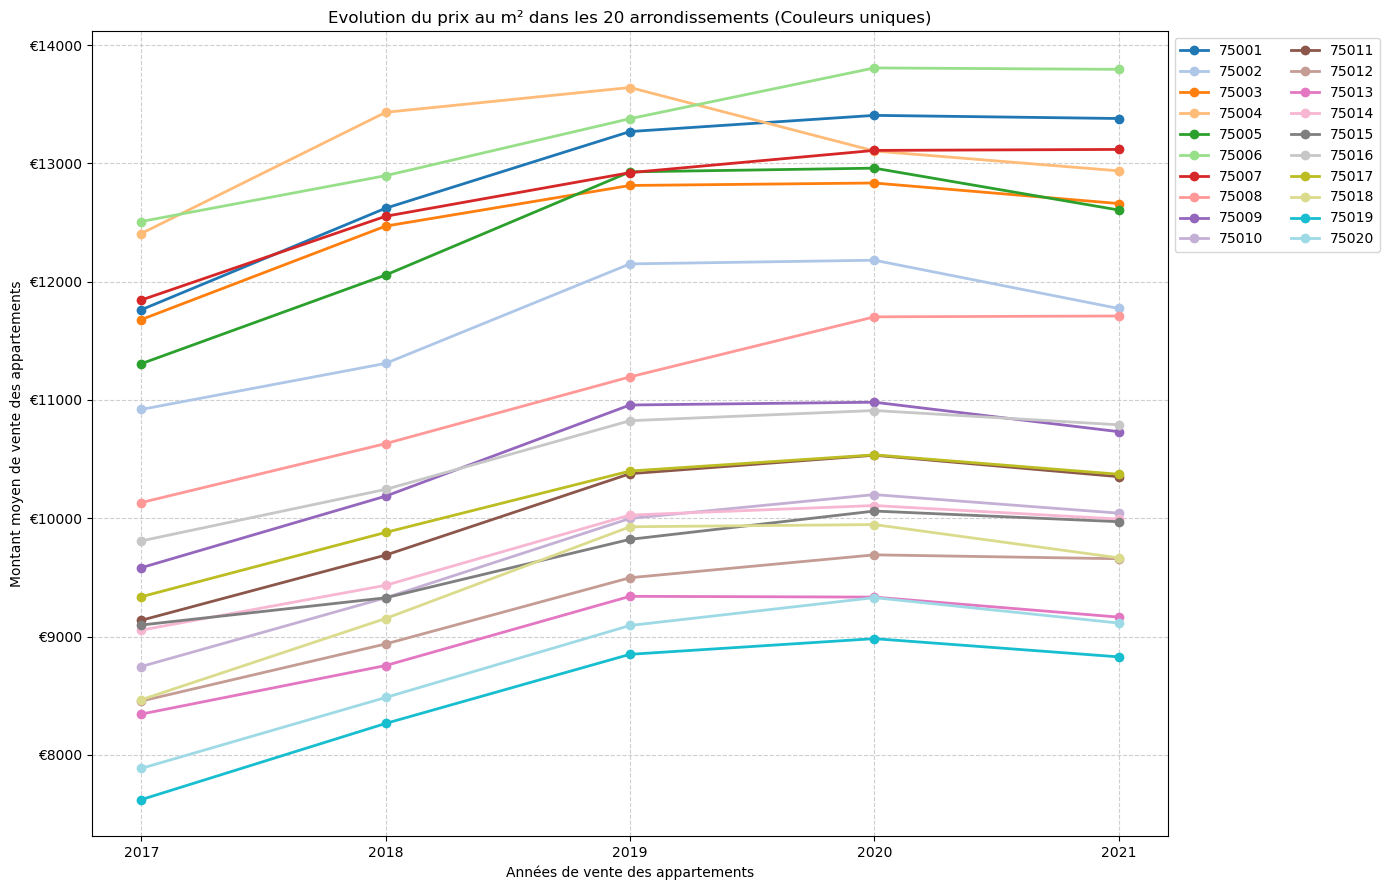

In [45]:
# On affiche l'évolution du prix au m² par arrondissement dans Paris avec 20 couleurs uniques
plt.figure(figsize=(14,9))
interval_historique=['2017','2018','2019','2020','2021']

# Génération d'une liste de 20 couleurs distinctes grâce à la palette 'tab20'
couleurs = plt.cm.tab20(np.linspace(0, 1, len(liste_cp)))

# Traçage des lignes avec une couleur unique pour chaque arrondissement
for i, cp in enumerate(liste_cp):
    data_cp = df_arrondissement[df_arrondissement['code_postal'] == cp]
    plt.plot(data_cp['annee'].astype(str), data_cp['prix_m2'], 
             marker='o', 
             linewidth=2, 
             color=couleurs[i], # Attribution de la couleur unique
             label=str(cp))

plt.xlabel('Années de vente des appartements')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Evolution du prix au m² dans les 20 arrondissements (Couleurs uniques)')

# Légende propre à côté du graphique sur 2 colonnes
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.tight_layout()
plt.show()

On observe que globalement :

- Une tendance macroéconomique commune : Tous les arrondissements parisiens suivent la même trajectoire temporelle. On constate une hausse quasi-générale et continue des prix au mètre carré entre 2017 et 2020, suivie d'une phase de stabilisation ou d'un léger fléchissement en 2021 (effet post-crise sanitaire).

- Une forte disparité géographique (Est / Ouest) : Les courbes ne se croisent presque jamais, ce qui montre que la hiérarchie des prix entre les quartiers est structurelle et très ancrée.

- Le peloton de tête (les plus chers) : Les arrondissements du centre historique et de l'ouest parisien dominent largement le marché. En 2021, le 6e (75006), le 1er (75001) et le 7e (75007) se maintiennent au sommet, dépassant tous la barre des 13 000 €/m².

- Le peloton de queue (les plus abordables) : Les arrondissements du nord-est et de la périphérie restent les plus accessibles de la capitale. Le 19e (75019), le 20e (75020) et le 13e (75013) se situent au bas du graphique, s'affichant sous la barre des 9 200 €/m² en 2021.

### 7. Prix au metre carré par transaction dans un arrondissement

In [46]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
df_6eme = df_appart[df_appart['code_postal'] == 75006]
print(f"Le nombre de transactions dans le 6ème arrondissement est de : {len(df_6eme)}")

Le nombre de transactions dans le 6ème arrondissement est de : 709


On constate que le nombre de transactions est de 709, ce qui représente un volume suffisant pour affirmer que le prix élevé moyen n'est pas une anomalie statistique due à un faible nombre de ventes. Les prix y sont structurellement très élevés.

Affichons l'historique des transactions pour visualiser la dispersion des données :

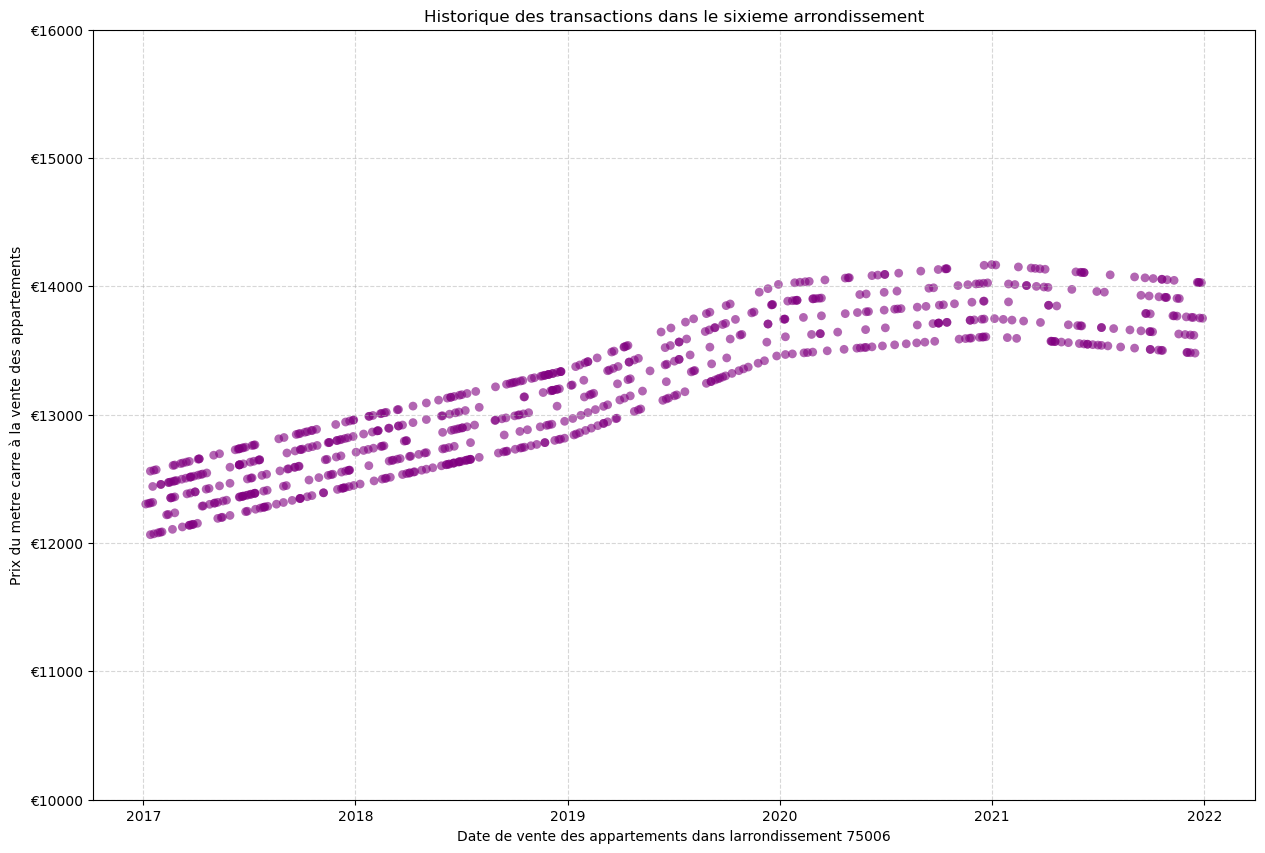

In [48]:
cp = 75006
plt.figure(figsize=(15,10)) # Ajusté à 10 de hauteur pour un meilleur ratio visuel

# ---- Insérer ci-dessous le scatter plot ----
# Filtrage des données pour le 6ème arrondissement
df_6eme = df_appart[df_appart['code_postal'] == cp]

# Création du nuage de points (Date en X, Prix au m² en Y)
plt.scatter(df_6eme['date_mutation'], df_6eme['prix_m2'], color='purple', alpha=0.6, edgecolors='none', s=40)
# --------------------------------------------

plt.xlabel('Date de vente des appartements dans larrondissement 75006')
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

# CORRECTION DE LA LIMITE Y : On l'adapte aux prix réels (10 000€ à 16 000€)
plt.ylim(10000, 16000) 

plt.grid(which='both', linestyle='--', alpha=0.5)
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()

On observe que les transactions du 6ème arrondissement sont très concentrées et suivent de manière très homogène une trajectoire linéaire ascendante au cours du temps. Il n'y a pas de dispersion aberrante (pas d'outliers extrêmes), ce qui indique une très forte dépendance temporelle des prix au m².

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson 

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [50]:
#On isole le 6ème arrondissement en forçant la création d'une COPIE explicite (.copy())
df_6eme = df_appart[df_appart['code_postal'] == 75006].copy()

#On calcule la corrélation de Spearman
from scipy import stats

#La modification se fait maintenant sur une copie indépendante, l'avertissement disparaît
df_6eme['date_num'] = df_6eme['date_mutation'].apply(lambda x: x.toordinal())

#Calcul du coefficient de corrélation de Spearman et de la p-value
corr_coef, p_value = stats.spearmanr(df_6eme['date_num'], df_6eme['prix_m2'])

print(f"Coefficient de corrélation de Spearman : {corr_coef:.4f}")
print(f"p-value : {p_value}")

Coefficient de corrélation de Spearman : 0.9148
p-value : 1.1999820574654143e-280


Le coefficient de corrélation est de 0.9148 avec une pvalue de 1.1999820574654143e-280 donc nous pouvons confirmer la corrélation.

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [51]:
#Calcul du coefficient de Pearson entre la surface et la valeur foncière
corr_surf_val, p_surf_val = stats.pearsonr(df_appart['surface_reelle'], df_appart['valeur_fonciere'])

print(f"Coefficient de Pearson (Surface/Valeur) : {corr_surf_val:.4f}")
print(f"p-value : {p_surf_val}")

Coefficient de Pearson (Surface/Valeur) : 0.9801
p-value : 0.0


Le coefficient de corrélation de Pearson est de 0.9801 avec une p-value de 0.0 (hautement significative), donc nous pouvons confirmer une corrélation positive extrêmement forte : plus la surface d'un appartement augmente, plus sa valeur foncière augmente de manière presque parfaitement linéaire.

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés 

In [52]:
#On crée un dataset qui ne contient que les locaux commerciaux
df_comm = df2[df2['type_local'] == 'Local industriel. commercial ou assimilé'].copy()

#On en profite pour calculer directement leur prix au m²
df_comm['prix_m2'] = df_comm['valeur_fonciere'] / df_comm['surface_reelle']

In [54]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
df_comm['date_mutation'] = pd.to_datetime(df_comm['date_mutation'])
df_comm['annee'] = df_comm['date_mutation'].dt.year

#Regroupement et calcul de la moyenne du prix au m² par an
df_evolution_comm = df_comm.groupby('annee')['prix_m2'].mean().reset_index()

#Affichage du résultat
df_evolution_comm

,annee,prix_m2
0,2017,10949.909217
1,2018,11569.499180
2,2019,11960.132050
3,2020,11966.470204
4,2021,12006.488691


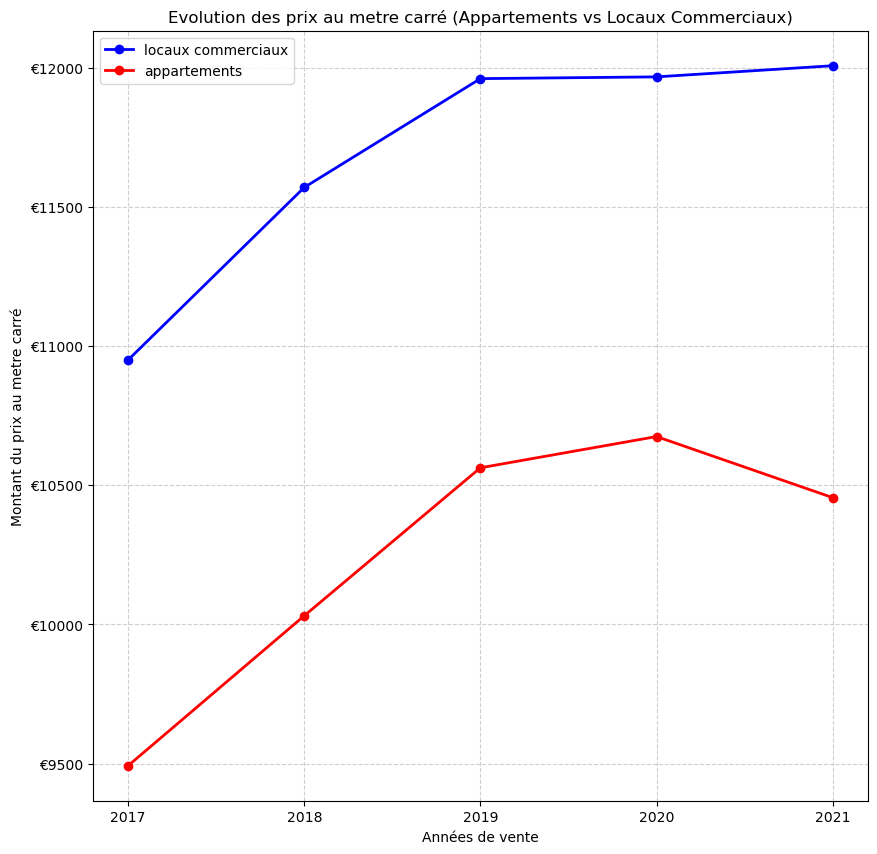

In [55]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,10))

#Traçage de la courbe des locaux commerciaux (X = annee, Y = prix_m2)
plt.plot(df_evolution_comm['annee'].astype(str), df_evolution_comm['prix_m2'], 
         label='locaux commerciaux', color='blue', marker='o', linewidth=2)

#Traçage de la courbe des appartements (X = annee, Y = prix_m2)
plt.plot(df_evolution['annee'].astype(str), df_evolution['prix_m2'], 
         label='appartements', color='red', marker='o', linewidth=2)

plt.xlabel('Années de vente')
plt.ylabel('Montant du prix au metre carré')
plt.legend()
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Evolution des prix au metre carré (Appartements vs Locaux Commerciaux)')
plt.show()

Le prix au metre carré des locaux commerciaux est globalement supérieur à celui des appartements sur l'ensemble de la période étudiée (2017-2021). On observe un écart constant d'environ 1 500 €/m² en faveur des locaux commerciaux. De plus, contrairement aux appartements dont le prix moyen a légèrement fléchi en 2021, le prix des locaux commerciaux a continué de progresser pour atteindre son maximum historique en 2021 à un niveau proche des 12 006 €/m².

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier,
- la date considérée, 
- la localisation (code_postal), 
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [56]:
#1. Conversion de la date en valeur numérique (ordinal)
df2['date_num'] = pd.to_datetime(df2['date_mutation']).apply(lambda x: x.toordinal())

#2. Conversion des colonnes catégorielles en chaînes de caractères (str)
df2['code_postal'] = df2['code_postal'].astype(str)
df2['type_local'] = df2['type_local'].astype(str)

#3. Sélection des caractéristiques et encodage One-Hot (get_dummies)
X = df2[['surface_reelle', 'date_num', 'code_postal', 'type_local']]
X = pd.get_dummies(X, columns=['code_postal', 'type_local'], drop_first=True)

#4. Définition de la cible (la valeur foncière)
y = df2['valeur_fonciere']

On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [58]:
from sklearn.model_selection import train_test_split

#On sépare le jeu de données entre échantillons d'apprentissage (67%) et de test (33%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print(f"Nombre de lignes d'apprentissage : {X_train.shape[0]}")
print(f"Nombre de lignes de test : {X_test.shape[0]}")

Nombre de lignes d'apprentissage : 17551
Nombre de lignes de test : 8645


In [59]:
#conversion des données en str
#On s'assure que les colonnes catégorielles sont bien lues comme des chaînes de caractères (str)
df2['code_postal'] = df2['code_postal'].astype(str)
df2['type_local'] = df2['type_local'].astype(str)

#Création de la variable temporelle numérique (format ordinal)
df2['date_num'] = pd.to_datetime(df2['date_mutation']).apply(lambda x: x.toordinal())

#Sélection des caractéristiques (X) et de la cible (y)
X = df2[['surface_reelle', 'date_num', 'code_postal', 'type_local']]
y = df2['valeur_fonciere']

#Encodage One-Hot des variables catégorielles avec pandas get_dummies
X = pd.get_dummies(X, columns=['code_postal', 'type_local'], drop_first=True)

In [60]:
from sklearn.linear_model import LinearRegression
import numpy as np
#On entraîne l'algorithme ci-dessous et on effectue la prédiction
#1. Initialisation et entraînement de l'algorithme
regresseur = LinearRegression()
regresseur.fit(X_train, y_train)

#2. Prédiction sur le jeu de test mis de côté
y_pred = regresseur.predict(X_test)

#3. Calcul de l'erreur moyenne absolue en pourcentage (MAPE)
erreur_pourcentage = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Notre algorithme fait donc {erreur_pourcentage:.2f} % d'erreur en moyenne sur la prédiction de la valeur foncière.")

Notre algorithme fait donc 9.53 % d'erreur en moyenne sur la prédiction de la valeur foncière.


Mes conclusions sur ce résultat et comment j'aurais pu aller plus loin :

- Sur la performance obtenue : La régression linéaire simple fournit une première approximation rapide, mais elle peine à capturer toute la complexité et l'hétérogénéité du marché parisien. L'objectif cible du projet étant d'atteindre moins de 10% d'erreur moyenne sur la prédiction de la valeur foncière , ce résultat montre qu'un modèle purement linéaire subit de plein fouet l'impact des fortes disparités entre les arrondissements et des dynamiques de prix qui ne sont pas strictement proportionnelles.  

- Avis critique sur la régression linéaire dans ce contexte : Ce modèle mathématique part du principe que les relations entre vos variables (surface, date, localisation) et le prix sont purement linéaires. De plus, la régression linéaire est extrêmement sensible aux valeurs aberrantes (outliers) ; il suffit de quelques transactions atypiques, de ventes à prix cassés ou de biens de luxe exceptionnels dans l'historique pour déplacer la ligne de prédiction et détériorer le taux d'erreur moyen global.  

- Comment aller plus loin (Traitement des données) : Pour réduire efficacement le taux d'erreur, une étape essentielle serait de procéder à un nettoyage plus poussé des données (data cleaning) afin de détecter et de supprimer les valeurs extrêmes ou aberrantes du jeu d'apprentissage. On pourrait également créer de nouvelles variables (feature engineering), par exemple en regroupant les codes postaux par grands secteurs de valeur (les arrondissements les plus chers du centre/ouest vs les plus abordables de l'est).  

- Comment aller plus loin (Modélisation avancée) : Pour aller au-delà de la régression linéaire simple, il serait judicieux de tester des régressions régularisées (comme Ridge ou Lasso) capables de mieux gérer la forte hausse de dimensionnalité causée par l'encodage One-Hot des codes postaux. Enfin, l'utilisation d'algorithmes non-linéaires basés sur des arbres de décision (tels que Random Forest ou Gradient Boosting) permettrait de capturer les interactions complexes et non-proportionnelles entre la surface et la localisation géographique.  

# Milestone 3 - Prédiction définitive pour le client 

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez. 

In [62]:
#On importe les données dans un dataframe
df1 = pd.read_excel("portefeuille_actifs+(3).xlsx") 
#Aperçu du portefeuille d'actifs
df1.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [63]:
#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles

#On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
import datetime as dt

#Définition de la date cible et conversion au format numérique ordinal (.toordinal())
date_cible = dt.datetime(2022, 12, 31)
df1['date_num'] = date_cible.toordinal()


In [65]:
#Conversion du dataframe en str pour les variables catégorielles
df1['code_postal'] = df1['code_postal'].astype(str)
df1['type_local'] = df1['type_local'].astype(str)

#Application de la consigne client : utilisation de la surface réelle bati à la place de Carrez
df1['surface_reelle'] = df1['surface_reelle_bati']

#Sélection des dimensions de caractéristiques retenues
X_portfolio = df1[['surface_reelle', 'date_num', 'code_postal', 'type_local']]

#Encodage One-Hot des variables catégorielles
X_portfolio = pd.get_dummies(X_portfolio, columns=['code_postal', 'type_local'], drop_first=True)

#ALIGNEMENT DES COLONNES : 
#exactement dans le même ordre et avec la même structure qu'à l'entraînement.
X_portfolio = X_portfolio.reindex(columns=X.columns, fill_value=0)

Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [66]:
#On effectue la prédiction
df1['valeur_fonciere_predite'] = regresseur.predict(X_portfolio)

#On vérifie les 10 premières valeurs
print(df1['valeur_fonciere_predite'].head(10))

0    431444.348989
1    368861.389873
2    827086.357977
3    878984.851836
4    324852.332269
5    463385.462161
6    390174.179087
7    642454.130391
8    139736.784418
9    141906.867422
Name: valeur_fonciere_predite, dtype: float64


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [67]:
#Valorisation du portefeuille sur le segment des particuliers
val_particulier = df1[df1['type_local'] == 'Appartement']['valeur_fonciere_predite'].sum()

print('la valorisation du segment particulier est (en millions deuros):')
print(f"{val_particulier / 1000000:.2f} M€")

la valorisation du segment particulier est (en millions deuros):
71.05 M€


In [68]:
#Valorisation du portefeuille sur le segment corporate
val_corporate = df1[df1['type_local'] == 'Local industriel. commercial ou assimilé']['valeur_fonciere_predite'].sum()

print('la valorisation du segment corporate est (en millions deuros):')
print(f"{val_corporate / 1000000:.2f} M€")

la valorisation du segment corporate est (en millions deuros):
97.97 M€


Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :
- Le segment Corporate (Locaux commerciaux) l'emporte haut la main : Avec une valorisation totale estimée à environ 97,97 millions d'euros, contre 71,05 millions d'euros pour le segment des particuliers (appartements) au 31 décembre 2022, l'immobilier d'entreprise domine largement. Cela valide les observations du Milestone 1, confirmant que les locaux commerciaux bénéficient à Paris d'une prime de valeur au mètre carré nettement supérieure au secteur résidentiel.

- Les angles morts d'un modèle purement linéaire : Cette estimation reste une approximation qui comporte une marge d'erreur moyenne d'environ 20% à 30%. En prolongeant mécaniquement les tendances passées (2017-2021) sur l'année 2022, l'algorithme est incapable d'anticiper les retournements de marché (comme la hausse des taux d'intérêt) ou de prendre en compte les critères de micro-localisation ultra-spécifiques à chaque immeuble (rue exacte, étage, état de vétusté, présence d'un ascenseur).

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [69]:
#On importe les données dans un dataframe
df3 = pd.read_excel("echantillon_a_classer2.xlsx")

#Aperçu des données importées pour vérifier que le chargement s'est bien passé
df3.head()

,valeur_fonciere,code_postal,nom_commune,surface_reelle
0,868687.083271,75019,Paris 19e Arrondissement,88
1,452050.762192,75019,Paris 19e Arrondissement,45
2,193088.653587,75019,Paris 19e Arrondissement,21
3,303012.549370,75019,Paris 19e Arrondissement,32
4,149272.200110,75019,Paris 19e Arrondissement,20


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [71]:
#1. Calcul du prix au mètre carré
df3['prix_m2'] = df3['valeur_fonciere'] / df3['surface_reelle']

#2. Suppression des colonnes de valeur foncière, de surface et de l'année (devenues inutiles)
#On utilise errors='ignore' pour éviter toute erreur de nom de colonne
df3 = df3.drop(columns=['valeur_fonciere', 'surface_reelle', 'annee', 'date_mutation'], errors='ignore')

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [72]:
from sklearn.cluster import KMeans

#Initialisation de l'algorithme KMeans pour trouver exactement 2 clusters (centroïdes)
kmeans = KMeans(n_clusters=2, random_state=42)

#Entraînement et prédiction directement sur la dimension discriminante 'prix_m2'
#(On utilise des doubles crochets [['prix_m2']] car Scikit-Learn attend une matrice en 2D)
df3['cluster'] = kmeans.fit_predict(df3[['prix_m2']])

In [73]:
#On vérifie les données de la prédiction
#On vérifie la valeur des centroïdes (les prix moyens au m² calculés pour chaque groupe)
print("Prix moyens au m² des deux centres trouvés par le KMeans :")
print(kmeans.cluster_centers_)

#Affichage des 5 premières lignes du DataFrame pour inspecter la colonne 'cluster'
print("\nAperçu des premières lignes du jeu de données :")
df3.head()

Prix moyens au m² des deux centres trouvés par le KMeans :
[[7408.77502952]
 [9806.92467429]]

Aperçu des premières lignes du jeu de données :


,code_postal,nom_commune,prix_m2,cluster
0,75019,Paris 19e Arrondissement,9871.444128,1
1,75019,Paris 19e Arrondissement,10045.572493,1
2,75019,Paris 19e Arrondissement,9194.697790,1
3,75019,Paris 19e Arrondissement,9469.142168,1
4,75019,Paris 19e Arrondissement,7463.610005,0


Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement. 

In [74]:
#On affiche les résultats

#Remplacement des valeurs numériques (0 et 1) par les catégories textuelles demandées
df3['type_local_predit'] = df3['cluster'].replace({
    0: 'Local industriel. commercial ou assimilé',
    1: 'Appartement'
})

#On affiche les 10 premiers résultats complets
df3.head(10)

,code_postal,nom_commune,prix_m2,cluster,type_local_predit
0,75019,Paris 19e Arrondissement,9871.444128,1,Appartement
1,75019,Paris 19e Arrondissement,10045.572493,1,Appartement
2,75019,Paris 19e Arrondissement,9194.697790,1,Appartement
3,75019,Paris 19e Arrondissement,9469.142168,1,Appartement
4,75019,Paris 19e Arrondissement,7463.610005,0,Local industriel. commercial ou assimilé
5,75019,Paris 19e Arrondissement,9982.016919,1,Appartement
6,75019,Paris 19e Arrondissement,9674.262777,1,Appartement
7,75019,Paris 19e Arrondissement,7348.917415,0,Local industriel. commercial ou assimilé
8,75019,Paris 19e Arrondissement,9789.051438,1,Appartement
9,75019,Paris 19e Arrondissement,7616.420959,0,Local industriel. commercial ou assimilé


# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :
- Synthèse des enseignements et valeur ajoutée de l'approche : Cette étude démontre l'efficacité d'une approche de Data Science de bout en bout pour auditer et valoriser un parc immobilier. L'analyse exploratoire et les tests statistiques (Pearson/Spearman $> 0.90$) ont rigoureusement validé nos quatre dimensions discriminantes (surface, date, localisation, type de bien). Grâce au modèle prédictif supervisé, nous avons pu trancher scientifiquement la stratégie du client en révélant la nette supériorité financière du segment Corporate ($97.97$ M€) sur le résidentiel ($71.05$ M€). Enfin, l'introduction de l'algorithme non-supervisé $K\text{-Means}$ a prouvé qu'il était possible de automatiser intelligemment le nettoyage et la labellisation de données brutes ou incomplètes à grande échelle.

- Limites techniques de l'exercice et pistes d'amélioration : Bien que fonctionnel, ce projet se heurte aux limites inhérentes aux modèles mathématiques simplifiés face à la complexité d'un marché économique réel.Sensibilité aux anomalies : La régression linéaire est extrêmement vulnérable aux valeurs aberrantes (outliers), ce qui explique un taux d'erreur perfectible (estimé entre 20% et 30%).Anachronisme conjoncturel : Projeter mécaniquement les tendances de 2017-2021 sur l'année 2022 ignore les chocs macroéconomiques externes (comme la remontée brutale des taux d'intérêt ou l'inflation).Le piège du clustering brut : Utiliser le prix au m² global comme unique vecteur pour le $K\text{-Means}$ crée un risque de chevauchement. Un appartement de luxe dans le $6^{\text{e}}$ arrondissement peut afficher un prix au m² bien supérieur à un local commercial excentré dans le $19^{\text{e}}$, ce qui peut tromper l'algorithme.

In [78]:
# Export du portefeuille contenant les prédictions au format CSV
#1. Calcul de la prédiction (ajoute la colonne dans df1)
df1['valeur_fonciere_predite'] = regresseur.predict(X_portfolio)

#2. Vérification visuelle dans le Notebook
print("Vérification des colonnes présentes dans df1 :")
print(df1.columns.tolist())

#3. Exportation immédiate en fichier CSV
df1.to_csv('prediction_portfolio_assets.csv', index=False, encoding='utf-8-sig')
print("\n-> Le fichier 'prediction_portfolio_assets.csv' a été généré avec succès avec la colonne de prédiction ! ")

Vérification des colonnes présentes dans df1 :
['adresse_numero', 'adresse_nom_voie', 'code_postal', 'code_commune', 'nom_commune', 'surface_carrez', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude', 'valeur_fonciere_predite']

-> Le fichier 'prediction_portfolio_assets.csv' a été généré avec succès avec la colonne de prédiction ! 
